# MedAssist-AI-IMAGE — Machine Learning Clásico (v2 completo)

## Clasificación multiclase de imágenes de medicamentos

**Versión mejorada** respecto a `ML_macroclase_completo`. Diseñada para ser un trabajo de nivel TFM:
extracción de features clásicos, exploración rigurosa, comparación de múltiples familias de modelos,
optimización, análisis estadístico y ablation studies.

---

## Índice

**BLOQUE 0 — Setup y datos**
0. [Dependencias y configuración global](#0)
1. [Carga del dataset balanceado (desde el EDA)](#1)
2. [Verificación del split y leakage](#2)
3. [Codificación de etiquetas](#3)

**BLOQUE 1 — Extracción de features**
4. [Diseño de features: Color HSV · HOG · LBP · Gabor · Moments](#4)
5. [Extracción masiva con caché y versionado](#5)
6. [Escalado y análisis de dimensionalidad](#6)

**BLOQUE 2 — Análisis exploratorio de features**
7. [Importancia de features por bloque y por clase](#7)
8. [PCA + t-SNE + UMAP](#8)
9. [Separabilidad teórica: score de Fisher](#9)

**BLOQUE 3 — Modelos base**
10. [Baselines (mayoría, aleatorio, Dummy)](#10)
11. [Family of models: LR · SVM · RF · GB · XGBoost · LightGBM · KNN · ExtraTrees](#11)
12. [Validación cruzada estratificada por grupo (StratifiedGroupKFold)](#12)

**BLOQUE 4 — Optimización**
13. [GridSearchCV — Random Forest](#13)
14. [RandomizedSearchCV — SVM](#14)
15. [Optuna / Halving Search — Gradient Boosting](#15)

**BLOQUE 5 — Ensembles**
16. [Voting Classifier (soft + hard)](#16)
17. [Stacking con meta-learner](#17)

**BLOQUE 6 — Ablation studies (crítico para nota alta)**
18. [Ablation 1: con vs sin augmentation offline](#18)
19. [Ablation 2: class_weight vs oversampling vs nada](#19)
20. [Ablation 3: importancia relativa de cada bloque de features](#20)

**BLOQUE 7 — Evaluación exhaustiva**
21. [Curvas ROC, PR y calibración (reliability diagram)](#21)
22. [Curvas de aprendizaje](#22)
23. [Test de significancia estadística (McNemar)](#23)
24. [Análisis profundo de errores con imágenes reales](#24)

**BLOQUE 8 — Evaluación final**
25. [Evaluación en test (una única vez)](#25)
26. [Comparativa Val vs Test — sobreajuste al proceso de selección](#26)
27. [Guardado del pipeline de producción con metadata](#27)

**BLOQUE 9 — Conclusiones**
28. [Síntesis de resultados y transición al Deep Learning](#28)

---

### Cambios principales respecto a la versión anterior

| Área | Antes | Ahora |
|---|---|---|
| **Datos** | Split en este notebook | Carga `dataset_balanced.csv` del EDA con split ya hecho |
| **Features** | Color HSV + HOG + LBP | + Gabor filters + Color moments + estadísticas HSV globales |
| **CV** | `cv=5` simple | `StratifiedGroupKFold` respetando `nregistro` |
| **Modelos** | 4 (SVM, RF, GB, KNN) | 8+ (LR, SVM, RF, ExtraTrees, GB, XGBoost, LightGBM, KNN) |
| **Ensembles** | Solo Voting | Voting (soft+hard) + Stacking con meta-learner |
| **Ablations** | No había | 3 estudios (augmentation, balanceo, features) |
| **Test stats** | No | McNemar entre top-2 modelos |
| **Calibración** | No | Reliability diagram + Brier score |
| **Learning curves** | No | Incluidas para el mejor modelo |
| **Error analysis** | Tabla de pares | + Visualización de imágenes + análisis por confianza |
| **Persistencia** | Solo modelo `.pkl` | Pipeline completo + JSON de metadata versionado |


<a id='0'></a>
## 0. Dependencias y configuración global


In [3]:
# Instalación (descomenta si hace falta)
# !pip install scikit-learn scikit-image pandas numpy matplotlib seaborn pillow
# !pip install opencv-python-headless imbalanced-learn joblib tqdm
# !pip install xgboost lightgbm umap-learn optuna

import warnings, random, os, time, json, sys, platform
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Núcleo científico ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# ── Imágenes ─────────────────────────────────────────────────────────────────
from PIL import Image
import cv2
from skimage.feature import hog, local_binary_pattern
from skimage.filters import gabor_kernel
from skimage.color import rgb2gray
from scipy import ndimage as ndi
from scipy.stats import loguniform, randint, uniform

# Necesario para usar HalvingRandomSearchCV / HalvingGridSearchCV
from sklearn.experimental import enable_halving_search_cv  # noqa: F401

# ── Machine Learning ─────────────────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split, StratifiedGroupKFold, GroupKFold,
    GridSearchCV, RandomizedSearchCV, cross_val_score,
    cross_validate, learning_curve, HalvingRandomSearchCV
)
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Clasificadores
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, VotingClassifier, StackingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    balanced_accuracy_score, accuracy_score,
    brier_score_loss, log_loss, cohen_kappa_score,
    matthews_corrcoef
)
from sklearn.inspection import permutation_importance

# Try imports opcionales (no rompen si faltan)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import umap
    HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

# Visualización
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns

# Persistencia
import joblib

# ── Configuración global ─────────────────────────────────────────────────────
SEED      = 42
IMG_SIZE  = (224, 224)                    # resize estándar
TARGET    = 'macroclase_15_nombre'
GROUP_COL = 'nregistro'

# CSV balanceado procedente del notebook de EDA
CSV_BALANCED = 'output/dataset_balanced.csv'
CSV_ORIGINAL = 'output/dataset_split.csv'  # fallback si no hay balanceado

# Paths de salida
OUTPUT_DIR = Path('output_ml')
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR  = Path('feature_cache')
CACHE_DIR.mkdir(exist_ok=True)

# Clases de trabajo
CLASES = [
    'Cardiovascular',
    'Neurología y psiquiatría',
    'Antiinfecciosos sistémicos',
    'Respiratorio',
    'otros'
]
PALETTE = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']))

# Versionado del experimento (para trazabilidad)
EXPERIMENT_VERSION = 'ml_v2_' + datetime.now().strftime('%Y%m%d_%H%M')

# Reproducibilidad
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Estilo
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})
sns.set_style('whitegrid')

print(f'Experimento: {EXPERIMENT_VERSION}')
print(f'Python: {sys.version.split()[0]}  |  Platform: {platform.system()}')
print(f'Librerías opcionales: XGBoost={HAS_XGB}  LightGBM={HAS_LGB}  UMAP={HAS_UMAP}  Optuna={HAS_OPTUNA}')
print(f'Clases: {CLASES}')


Experimento: ml_v2_20260418_1135
Python: 3.9.6  |  Platform: Darwin
Librerías opcionales: XGBoost=True  LightGBM=True  UMAP=True  Optuna=True
Clases: ['Cardiovascular', 'Neurología y psiquiatría', 'Antiinfecciosos sistémicos', 'Respiratorio', 'otros']


<a id='1'></a>
## 1. Carga del dataset balanceado (desde el EDA)

Cargamos `dataset_balanced.csv` generado por el notebook de EDA. Este CSV ya trae:
- La columna `split` con `train/val/test` asignado a nivel de `nregistro` (sin leakage por medicamento)
- La columna `augmented` (True = imagen sintética de augmentation offline, solo en train)
- `clase` con las 5 macroclases finales (4 principales + `otros`)

Si el CSV balanceado no existe aún, usamos como fallback `dataset_split.csv`.

**Por qué esto importa**: reutilizar el split del EDA garantiza que las ablations (con/sin augmentation) usen **exactamente la misma partición train/val/test**, haciendo las comparativas válidas.


In [4]:
# Intentar cargar CSV balanceado; si no existe, usar el split original
if Path(CSV_BALANCED).exists():
    df = pd.read_csv(CSV_BALANCED, dtype={'nregistro': str})
    print(f'✔ Cargado: {CSV_BALANCED}')
elif Path(CSV_ORIGINAL).exists():
    df = pd.read_csv(CSV_ORIGINAL, dtype={'nregistro': str})
    df['augmented']       = False
    df['aug_source_path'] = np.nan
    df['aug_transform']   = np.nan
    print(f'⚠ CSV balanceado no encontrado, usando: {CSV_ORIGINAL}')
    print('  (sin augmentation offline disponible para ablation)')
else:
    raise FileNotFoundError(
        f'No se encuentra ni {CSV_BALANCED} ni {CSV_ORIGINAL}. '
        'Ejecuta primero el notebook de EDA.'
    )

# Saneamiento básico
df = df[df['clase'].notna() & df['image_path'].notna()].copy().reset_index(drop=True)

# Forzar orden de clases consistente
df['clase'] = pd.Categorical(df['clase'], categories=CLASES, ordered=False)
df = df[df['clase'].notna()].copy().reset_index(drop=True)

# Resumen
print('\n' + '='*65)
print('  DATASET CARGADO')
print('='*65)
print(f'  Total filas:                 {len(df):>8,}')
print(f'  Medicamentos únicos:         {df[GROUP_COL].nunique():>8,}')
print(f'  Imágenes originales:         {(~df["augmented"]).sum():>8,}')
print(f'  Imágenes sintéticas (aug):   {df["augmented"].sum():>8,}')
print(f'  Caja:                        {(df["image_type"]=="caja").sum():>8,}')
print(f'  Pastilla:                    {(df["image_type"]=="pastilla").sum():>8,}')
print()
print('  Distribución por split × augmented:')
print(df.groupby(['split','augmented']).size().unstack(fill_value=0).to_string())
print()
print('  Distribución de clases:')
print(df['clase'].value_counts().reindex(CLASES).to_string())


✔ Cargado: output/dataset_balanced.csv

  DATASET CARGADO
  Total filas:                   20,486
  Medicamentos únicos:            5,021
  Imágenes originales:            9,998
  Imágenes sintéticas (aug):     10,488
  Caja:                          10,202
  Pastilla:                      10,284

  Distribución por split × augmented:
augmented  False  True 
split                  
test        1499      0
train       6999  10488
val         1500      0

  Distribución de clases:
clase
Cardiovascular                4045
Neurología y psiquiatría      3979
Antiinfecciosos sistémicos    3731
Respiratorio                  3709
otros                         5022


<a id='2'></a>
## 2. Verificación del split y ausencia de leakage

Dos verificaciones críticas:
1. **No hay `nregistro` compartidos entre splits** (ya lo garantiza el EDA pero lo revalidamos).
2. **Las imágenes aumentadas están solo en `train`** (si no, habría leakage porque el augmentation parte de originales).


  VERIFICACIÓN DE LEAKAGE
  Train ∩ Val:      0  ✅ OK
  Train ∩ Test:     0  ✅ OK
  Val   ∩ Test:     0  ✅ OK

  Augmentation en val:      0  ✅ OK
  Augmentation en test:     0  ✅ OK


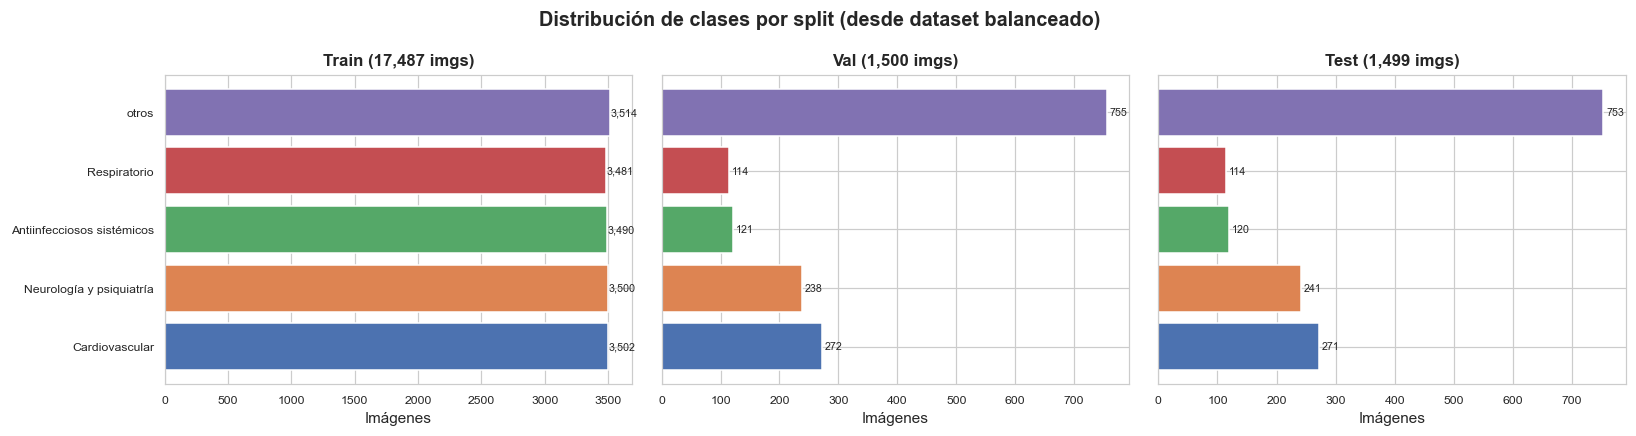

In [5]:
# ── Construir df_train, df_val, df_test ──────────────────────────────────────
df_train = df[df['split'] == 'train'].reset_index(drop=True)
df_val   = df[df['split'] == 'val'].reset_index(drop=True)
df_test  = df[df['split'] == 'test'].reset_index(drop=True)

# ── Verificación 1: sin leakage de medicamentos ──────────────────────────────
regs_train = set(df_train[GROUP_COL])
regs_val   = set(df_val[GROUP_COL])
regs_test  = set(df_test[GROUP_COL])

leak_tv = regs_train & regs_val
leak_tt = regs_train & regs_test
leak_vt = regs_val & regs_test

print('='*60)
print('  VERIFICACIÓN DE LEAKAGE')
print('='*60)
print(f'  Train ∩ Val:   {len(leak_tv):>4}  {"✅ OK" if not leak_tv else "❌ LEAKAGE"}')
print(f'  Train ∩ Test:  {len(leak_tt):>4}  {"✅ OK" if not leak_tt else "❌ LEAKAGE"}')
print(f'  Val   ∩ Test:  {len(leak_vt):>4}  {"✅ OK" if not leak_vt else "❌ LEAKAGE"}')

# ── Verificación 2: aug solo en train ────────────────────────────────────────
aug_val  = df_val['augmented'].sum()
aug_test = df_test['augmented'].sum()
print(f'\n  Augmentation en val:   {aug_val:>4}  {"✅ OK" if aug_val == 0 else "❌ FUGA"}')
print(f'  Augmentation en test:  {aug_test:>4}  {"✅ OK" if aug_test == 0 else "❌ FUGA"}')

# ── Visualización del split ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (nombre, dfs) in zip(axes, [('Train', df_train), ('Val', df_val), ('Test', df_test)]):
    cnt = dfs['clase'].value_counts().reindex(CLASES)
    ax.barh(CLASES, cnt.values, color=[PALETTE[c] for c in CLASES], edgecolor='white')
    ax.set_title(f'{nombre} ({len(dfs):,} imgs)', fontweight='bold')
    ax.set_xlabel('Imágenes')
    for i, v in enumerate(cnt.values):
        ax.text(v + 5, i, f'{v:,}', va='center', fontsize=7)
plt.suptitle('Distribución de clases por split (desde dataset balanceado)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_split_distribucion.png', bbox_inches='tight')
plt.show()


<a id='3'></a>
## 3. Codificación de etiquetas

`LabelEncoder` ajustado sobre la lista fija `CLASES` → orden determinista (no depende del orden del CSV).


In [6]:
le = LabelEncoder()
le.fit(CLASES)

y_train_raw = le.transform(df_train['clase'].values)
y_val_raw   = le.transform(df_val['clase'].values)
y_test_raw  = le.transform(df_test['clase'].values)

print('Mapeo clase → entero:')
for idx, cls in enumerate(le.classes_):
    print(f'  {idx}  →  {cls}')

print(f'\nShape inicial:  y_train={y_train_raw.shape}  y_val={y_val_raw.shape}  y_test={y_test_raw.shape}')


Mapeo clase → entero:
  0  →  Antiinfecciosos sistémicos
  1  →  Cardiovascular
  2  →  Neurología y psiquiatría
  3  →  Respiratorio
  4  →  otros

Shape inicial:  y_train=(17487,)  y_val=(1500,)  y_test=(1499,)


<a id='4'></a>
## 4. Diseño de features

### Bloques de features (ampliados respecto a la versión anterior)

| Bloque | Método | Dims aprox. | Qué captura |
|---|---|---|---|
| **Color HSV** | Histograma HSV con pirámide espacial 2×2 sobre canal H + momentos de S y V | 128 + 6 = 134 | Distribución de tono por zona + estadísticos de saturación/brillo |
| **HOG** | Histogram of Oriented Gradients (9 orient, cpb 16×16, bpb 2×2) sobre gris 128×128 | ~1,764 | Formas, bordes y siluetas |
| **LBP** | Local Binary Pattern uniforme (r=3, P=24) | 26 | Texturas locales |
| **Gabor** | Banco de 8 filtros de Gabor a 4 orientaciones × 2 frecuencias, media y std de la respuesta | 16 | Texturas orientadas (muy complementario a HOG/LBP) |
| **Color moments** | Media, std y skewness de cada canal RGB y HSV | 18 | Estadísticos de color globales, robustos al tamaño |

**Total** ≈ 1,960 features. Luego PCA reduce a ~100 dims con 95% varianza.

### Por qué estos bloques

- Color y textura + forma son los tres ejes clásicos de visión por computador para clasificación. Añadir Gabor (textura orientada) y momentos (estadísticos robustos) cubre casos donde HOG/LBP pueden fallar (imágenes blurry, clases con fondos homogéneos).


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# FUNCIONES DE EXTRACCIÓN
# ─────────────────────────────────────────────────────────────────────────────

def extract_color_histogram_hsv(img_rgb, bins=32, grid=(2,2)):
    """Histograma HSV con pirámide espacial sobre canal Hue + momentos de S y V."""
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    H, W = hsv.shape[:2]
    rows, cols = grid
    ch, cw = H // rows, W // cols

    feats = []
    # Histograma de Hue por celda
    for r in range(rows):
        for c in range(cols):
            patch = hsv[r*ch:(r+1)*ch, c*cw:(c+1)*cw, 0]
            h_, _ = np.histogram(patch, bins=bins, range=(0, 180))
            s = h_.sum()
            feats.append(h_ / s if s > 0 else h_.astype(float))
    # Momentos de Saturation y Value globales
    for ch_idx in [1, 2]:
        vals = hsv[:, :, ch_idx].astype(float)
        feats.append(np.array([vals.mean(), vals.std(), vals.min(), vals.max()]))
    return np.concatenate(feats)


def extract_color_moments(img_rgb):
    """Momentos (media, std, skew) de cada canal RGB y HSV — 18 features."""
    hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    out = []
    for img in [img_rgb, hsv]:
        for c in range(3):
            x = img[:, :, c].astype(float).ravel()
            mean = x.mean()
            std  = x.std() + 1e-9
            skew = ((x - mean) ** 3).mean() / (std ** 3)
            out.extend([mean, std, skew])
    return np.array(out, dtype=np.float32)


def extract_hog(img_rgb, size=(128, 128)):
    """HOG en gris — captura bordes y formas."""
    gray = rgb2gray(np.array(Image.fromarray(img_rgb).resize(size, Image.BILINEAR)))
    return hog(gray, orientations=9, pixels_per_cell=(16,16),
               cells_per_block=(2,2), block_norm='L2-Hys',
               feature_vector=True).astype(np.float32)


def extract_lbp(img_rgb, radius=3, n_points=24, size=(128, 128)):
    """LBP uniforme — captura texturas locales."""
    gray = rgb2gray(np.array(Image.fromarray(img_rgb).resize(size, Image.BILINEAR)))
    lbp  = local_binary_pattern(gray, P=n_points, R=radius, method='uniform')
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp, bins=n_bins, range=(0, n_bins), density=True)
    return hist.astype(np.float32)


# Banco de filtros de Gabor (se construye una vez)
_GABOR_KERNELS = []
for theta in np.arange(0, np.pi, np.pi / 4):      # 4 orientaciones: 0, 45, 90, 135
    for freq in [0.1, 0.3]:                        # 2 frecuencias
        kern = np.real(gabor_kernel(frequency=freq, theta=theta))
        _GABOR_KERNELS.append(kern)


def extract_gabor(img_rgb, size=(64, 64)):
    """Respuesta media y std a banco de 8 filtros Gabor — captura texturas orientadas."""
    gray = rgb2gray(np.array(Image.fromarray(img_rgb).resize(size, Image.BILINEAR)))
    feats = []
    for kern in _GABOR_KERNELS:
        filtered = ndi.convolve(gray, kern, mode='wrap')
        feats.extend([filtered.mean(), filtered.var()])
    return np.array(feats, dtype=np.float32)


def extract_features(image_path, include_blocks=('color','moments','hog','lbp','gabor')):
    """
    Pipeline completo para una imagen.
    Devuelve dict {bloque: vector} para poder hacer ablation por bloques.
    """
    try:
        img = Image.open(image_path).convert('RGB').resize(IMG_SIZE, Image.BILINEAR)
        arr = np.array(img)
    except Exception:
        return None

    out = {}
    if 'color'   in include_blocks: out['color']   = extract_color_histogram_hsv(arr)
    if 'moments' in include_blocks: out['moments'] = extract_color_moments(arr)
    if 'hog'     in include_blocks: out['hog']     = extract_hog(arr)
    if 'lbp'     in include_blocks: out['lbp']     = extract_lbp(arr)
    if 'gabor'   in include_blocks: out['gabor']   = extract_gabor(arr)
    return out


# Probar sobre una imagen para conocer las dimensiones
sample_row = df_train.iloc[0]
sample_feats = extract_features(sample_row['image_path'])
if sample_feats is not None:
    FEATURE_DIMS = {k: len(v) for k, v in sample_feats.items()}
    TOTAL_DIMS   = sum(FEATURE_DIMS.values())
    print('─' * 50)
    print('  DIMENSIONES POR BLOQUE')
    print('─' * 50)
    for k, d in FEATURE_DIMS.items():
        print(f'  {k:<10} {d:>6,} dims')
    print('─' * 50)
    print(f'  TOTAL      {TOTAL_DIMS:>6,} dims')
else:
    raise RuntimeError(f'No se pudo leer {sample_row["image_path"]}')


──────────────────────────────────────────────────
  DIMENSIONES POR BLOQUE
──────────────────────────────────────────────────
  color         136 dims
  moments        18 dims
  hog         1,764 dims
  lbp            26 dims
  gabor          16 dims
──────────────────────────────────────────────────
  TOTAL       1,960 dims


<a id='5'></a>
## 5. Extracción masiva con caché y versionado

Extraemos para cada split. **Guardamos cada bloque por separado** para poder luego hacer ablation (entrenar sin HOG, sin Gabor, etc.) sin recomputar.

### Caché versionada

El nombre del caché incluye la versión de features; si cambias el diseño, regenera pasando `force=True`.


In [8]:
FEATURES_VERSION = 'v2_color_moments_hog_lbp_gabor'


def extract_features_batch(df_split, split_name, force=False):
    """
    Extrae todos los bloques para un split. Cache por bloque.
    Devuelve un dict {bloque: np.ndarray (N, D)} + y + valid_mask.
    """
    cache_path = CACHE_DIR / f'feats_{FEATURES_VERSION}_{split_name}.pkl'

    if cache_path.exists() and not force:
        print(f'  [{split_name}] Cargando caché: {cache_path.name}')
        return joblib.load(cache_path)

    print(f'  [{split_name}] Extrayendo {len(df_split):,} imágenes...')
    t0 = time.time()
    blocks = {k: [] for k in ['color','moments','hog','lbp','gabor']}
    labels, valid_idx = [], []

    for i, row in enumerate(tqdm(df_split.itertuples(), total=len(df_split),
                                 desc=split_name)):
        feats = extract_features(row.image_path)
        if feats is None:
            continue
        for k in blocks:
            blocks[k].append(feats[k])
        labels.append(le.transform([row.clase])[0])
        valid_idx.append(i)

    # Stack
    blocks = {k: np.stack(v).astype(np.float32) for k, v in blocks.items()}
    y = np.array(labels, dtype=np.int32)
    valid_idx = np.array(valid_idx)

    result = {'blocks': blocks, 'y': y, 'valid_idx': valid_idx,
              'feature_dims': {k: v.shape[1] for k, v in blocks.items()}}
    joblib.dump(result, cache_path)

    elapsed = time.time() - t0
    print(f'  [{split_name}] ✅ {len(valid_idx):,} OK  |  '
          f'{len(df_split)-len(valid_idx)} errores  |  {elapsed:.0f}s')
    return result


print('Extrayendo features (esto tarda la primera vez)...\n')
feats_train = extract_features_batch(df_train, 'train')
feats_val   = extract_features_batch(df_val,   'val')
feats_test  = extract_features_batch(df_test,  'test')

# Construir X concatenando bloques
def concat_blocks(feats, include=('color','moments','hog','lbp','gabor')):
    return np.concatenate([feats['blocks'][k] for k in include], axis=1)

X_train = concat_blocks(feats_train)
X_val   = concat_blocks(feats_val)
X_test  = concat_blocks(feats_test)

y_train = feats_train['y']
y_val   = feats_val['y']
y_test  = feats_test['y']

# También guardamos groups y flags para CV por grupo y ablations
groups_train = df_train.iloc[feats_train['valid_idx']][GROUP_COL].values
is_aug_train = df_train.iloc[feats_train['valid_idx']]['augmented'].values

print(f'\n── Matrices finales ──')
print(f'  X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape}  y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape}  y_test:  {y_test.shape}')
print(f'  Groups (nregistro) únicos en train: {len(np.unique(groups_train)):,}')
print(f'  Imágenes aumentadas en train:       {is_aug_train.sum():,}')


Extrayendo features (esto tarda la primera vez)...

  [train] Extrayendo 17,487 imágenes...


train: 100%|██████████| 17487/17487 [04:07<00:00, 70.60it/s]



  [train] ✅ 6,971 OK  |  10516 errores  |  248s
  [val] Extrayendo 1,500 imágenes...


val: 100%|██████████| 1500/1500 [00:52<00:00, 28.40it/s]


  [val] ✅ 1,493 OK  |  7 errores  |  53s
  [test] Extrayendo 1,499 imágenes...


test: 100%|██████████| 1499/1499 [00:51<00:00, 29.01it/s]

  [test] ✅ 1,492 OK  |  7 errores  |  52s

── Matrices finales ──
  X_train: (6971, 1960)  y_train: (6971,)
  X_val:   (1493, 1960)  y_val:   (1493,)
  X_test:  (1492, 1960)  y_test:  (1492,)
  Groups (nregistro) únicos en train: 3,514
  Imágenes aumentadas en train:       0


<a id='6'></a>
## 6. Escalado y análisis de dimensionalidad

**Crítico**: el `StandardScaler` se ajusta **solo con train**; val y test se transforman con los mismos parámetros. Ajustar sobre todo el dataset sería data leakage.


In [9]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler ajustado solo con TRAIN:')
print(f'  X_train_sc — μ≈{X_train_sc.mean():.3f}  σ≈{X_train_sc.std():.3f}')
print(f'  X_val_sc   — μ≈{X_val_sc.mean():.3f}   σ≈{X_val_sc.std():.3f}')
print(f'  X_test_sc  — μ≈{X_test_sc.mean():.3f}  σ≈{X_test_sc.std():.3f}')
print(f'\nDimensionalidad: {X_train_sc.shape[1]:,} features')
print(f'Ratio samples/features en train: {X_train_sc.shape[0]/X_train_sc.shape[1]:.2f}')

joblib.dump(scaler, OUTPUT_DIR / 'scaler.pkl')


StandardScaler ajustado solo con TRAIN:
  X_train_sc — μ≈0.000  σ≈1.000
  X_val_sc   — μ≈0.004   σ≈1.008
  X_test_sc  — μ≈-0.003  σ≈1.003

Dimensionalidad: 1,960 features
Ratio samples/features en train: 3.56


['output_ml/scaler.pkl']

<a id='7'></a>
## 7. Importancia de features por bloque y por clase

Dos análisis:
1. **Importancia agregada por bloque** (Gini de un RF rápido) — ¿qué bloque aporta más?
2. **Permutation importance por clase** — ¿qué bloque es más útil para cada clase específica?


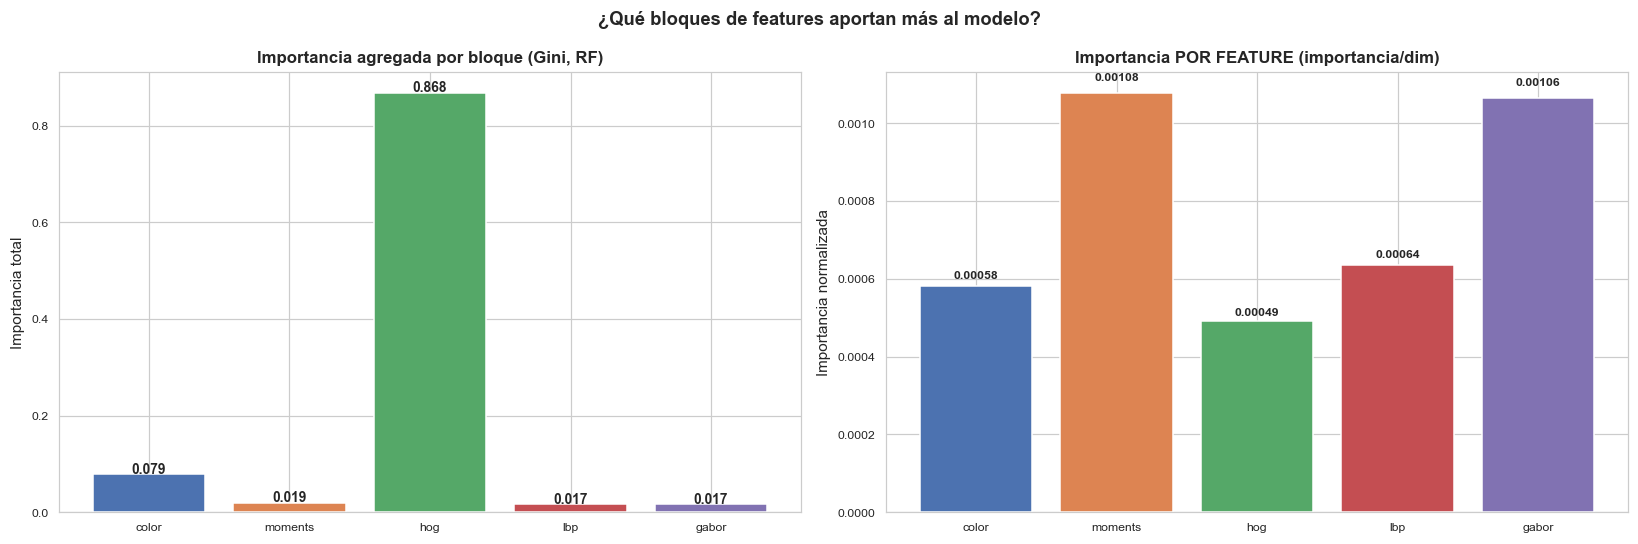

───────────────────────────────────────────────────────
  INTERPRETACIÓN
───────────────────────────────────────────────────────
  Importancia total: qué bloque pesa más en predicción.
  Importancia/feature: qué bloque es más "eficiente"
    (un bloque con pocas dims pero alta importancia total es muy informativo).


In [10]:
# ── Importancia Gini por bloque con RF rápido ────────────────────────────────
rf_quick = RandomForestClassifier(
    n_estimators=150, max_depth=10, class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf_quick.fit(X_train_sc, y_train)
importancias = rf_quick.feature_importances_

# Acumular por bloque
offsets = {}
cursor = 0
for k in ['color', 'moments', 'hog', 'lbp', 'gabor']:
    d = feats_train['feature_dims'][k]
    offsets[k] = (cursor, cursor + d)
    cursor += d

imp_por_bloque = {k: importancias[a:b].sum() for k, (a, b) in offsets.items()}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Barras por bloque
colors_block = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']
axes[0].bar(imp_por_bloque.keys(), imp_por_bloque.values(),
            color=colors_block, edgecolor='white')
axes[0].set_title('Importancia agregada por bloque (Gini, RF)', fontweight='bold')
axes[0].set_ylabel('Importancia total')
for i, (k, v) in enumerate(imp_por_bloque.items()):
    axes[0].text(i, v + 0.002, f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)

# Normalizar por número de features (relativa por feature)
imp_por_bloque_rel = {
    k: imp_por_bloque[k] / feats_train['feature_dims'][k]
    for k in imp_por_bloque
}
axes[1].bar(imp_por_bloque_rel.keys(), imp_por_bloque_rel.values(),
            color=colors_block, edgecolor='white')
axes[1].set_title('Importancia POR FEATURE (importancia/dim)', fontweight='bold')
axes[1].set_ylabel('Importancia normalizada')
for i, (k, v) in enumerate(imp_por_bloque_rel.items()):
    axes[1].text(i, v + v*0.03, f'{v:.5f}', ha='center', fontweight='bold', fontsize=8)

plt.suptitle('¿Qué bloques de features aportan más al modelo?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_feature_importance_bloques.png', bbox_inches='tight')
plt.show()

print('─' * 55)
print('  INTERPRETACIÓN')
print('─' * 55)
print('  Importancia total: qué bloque pesa más en predicción.')
print('  Importancia/feature: qué bloque es más "eficiente"')
print('    (un bloque con pocas dims pero alta importancia total es muy informativo).')


<a id='8'></a>
## 8. Reducción de dimensionalidad: PCA + t-SNE + UMAP

- **PCA** para alimentar modelos como SVM que se benefician de menos dimensiones.
- **t-SNE** para visualización (preserva vecindad local).
- **UMAP** para visualización (preserva tanto estructura local como global, suele ser más rápido y estable que t-SNE).


In [11]:
# ── PCA ──────────────────────────────────────────────────────────────────────
pca_full = PCA(n_components=min(300, X_train_sc.shape[1]), random_state=SEED)
pca_full.fit(X_train_sc)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

n_comp_90 = int(np.searchsorted(var_acum, 0.90)) + 1
n_comp_95 = int(np.searchsorted(var_acum, 0.95)) + 1
n_comp_99 = int(np.searchsorted(var_acum, 0.99)) + 1

print(f'PCA — componentes para explicar:')
print(f'  90% varianza: {n_comp_90:>4}  |  95%: {n_comp_95:>4}  |  99%: {n_comp_99:>4}')

pca_95 = PCA(n_components=n_comp_95, random_state=SEED)
X_train_pca = pca_95.fit_transform(X_train_sc)
X_val_pca   = pca_95.transform(X_val_sc)
X_test_pca  = pca_95.transform(X_test_sc)

joblib.dump(pca_95, OUTPUT_DIR / 'pca_95.pkl')
print(f'\nMatriz proyectada: X_train_pca {X_train_pca.shape}')


PCA — componentes para explicar:
  90% varianza:  301  |  95%:  301  |  99%:  301

Matriz proyectada: X_train_pca (6971, 301)

Matriz proyectada: X_train_pca (6971, 301)


Calculando t-SNE sobre 1,500 muestras...
Calculando UMAP...
Calculando UMAP...


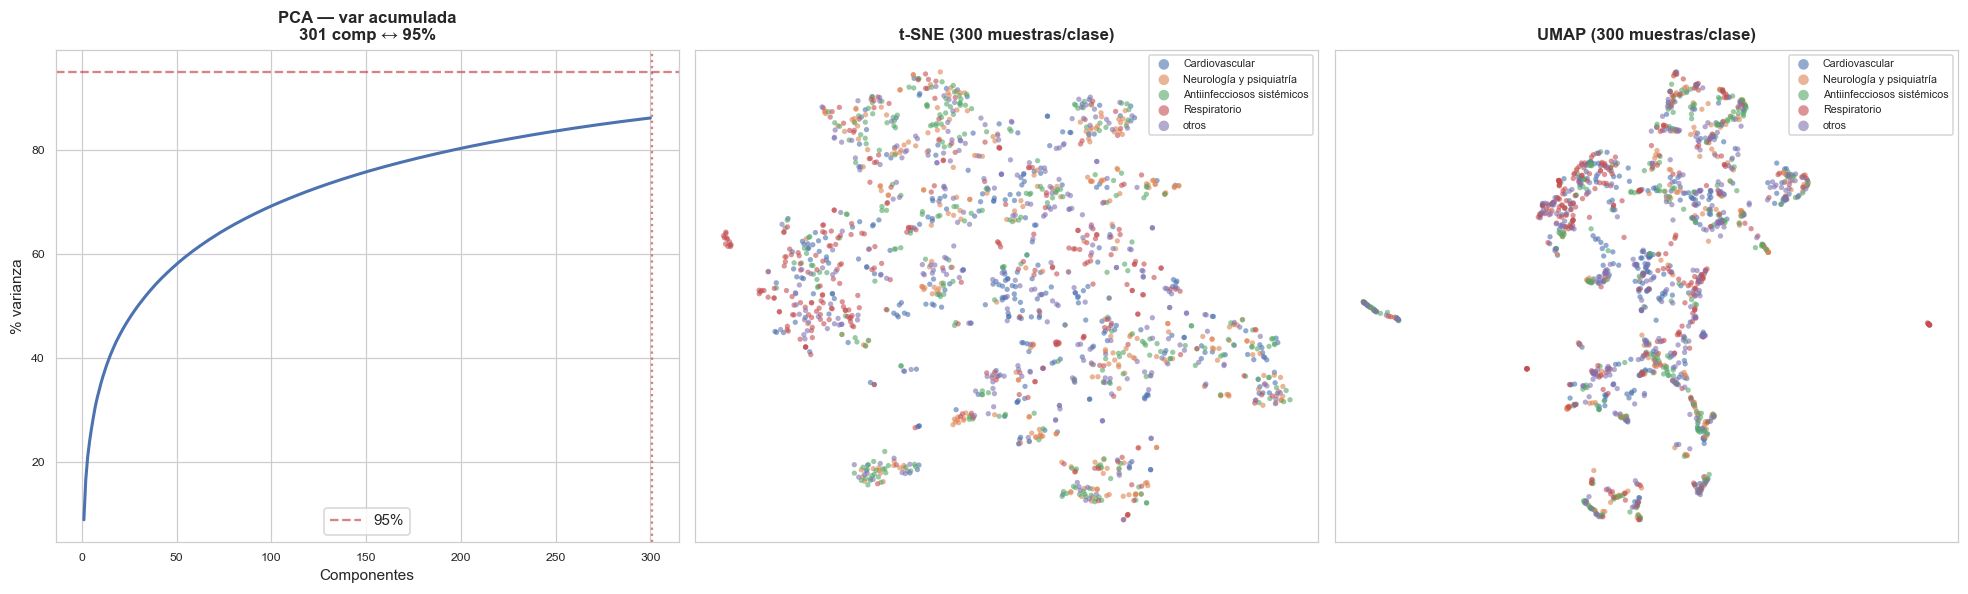

In [12]:
# ── t-SNE + UMAP sobre muestra balanceada ────────────────────────────────────
# Para visualización, balanceamos la muestra para no distorsionar la percepción
N_PER_CLASS = 300
idx_sample = []
for cls_idx in range(len(CLASES)):
    cand = np.where(y_train == cls_idx)[0]
    k = min(N_PER_CLASS, len(cand))
    idx_sample.extend(np.random.choice(cand, k, replace=False))
idx_sample = np.array(idx_sample)

X_sample = X_train_pca[idx_sample]
y_sample = y_train[idx_sample]

# Reducir primero con PCA a 50 dims antes de t-SNE (acelera y estabiliza)
pca50 = PCA(n_components=min(50, X_sample.shape[1]), random_state=SEED)
X_pca50 = pca50.fit_transform(X_sample)

print(f'Calculando t-SNE sobre {len(X_pca50):,} muestras...')
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            init='pca', random_state=SEED)
X_tsne = tsne.fit_transform(X_pca50)

# UMAP si está disponible
if HAS_UMAP:
    print(f'Calculando UMAP...')
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=SEED)
    X_umap = reducer.fit_transform(X_pca50)

# ── Visualización combinada ──────────────────────────────────────────────────
n_plots = 3 if HAS_UMAP else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5.5))

# PCA varianza
axes[0].plot(range(1, len(var_acum)+1), var_acum * 100, color='#4C72B0', lw=2)
axes[0].axhline(95, color='#C44E52', ls='--', label='95%', alpha=0.7)
axes[0].axvline(n_comp_95, color='#C44E52', ls=':', alpha=0.7)
axes[0].set_title(f'PCA — var acumulada\n{n_comp_95} comp ↔ 95%', fontweight='bold')
axes[0].set_xlabel('Componentes'); axes[0].set_ylabel('% varianza')
axes[0].legend()

# t-SNE
for cls_idx, cls in enumerate(CLASES):
    mask = y_sample == cls_idx
    axes[1].scatter(X_tsne[mask,0], X_tsne[mask,1],
                    c=PALETTE[cls], s=12, alpha=0.6, label=cls, edgecolors='none')
axes[1].set_title('t-SNE (300 muestras/clase)', fontweight='bold')
axes[1].legend(fontsize=7, markerscale=2)
axes[1].set_xticks([]); axes[1].set_yticks([])

# UMAP
if HAS_UMAP:
    for cls_idx, cls in enumerate(CLASES):
        mask = y_sample == cls_idx
        axes[2].scatter(X_umap[mask,0], X_umap[mask,1],
                        c=PALETTE[cls], s=12, alpha=0.6, label=cls, edgecolors='none')
    axes[2].set_title('UMAP (300 muestras/clase)', fontweight='bold')
    axes[2].legend(fontsize=7, markerscale=2)
    axes[2].set_xticks([]); axes[2].set_yticks([])

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_pca_tsne_umap.png', bbox_inches='tight')
plt.show()


<a id='9'></a>
## 9. Separabilidad teórica: Fisher Discriminant Score

El **Fisher score** mide, para cada feature, el ratio entre la varianza **entre clases** y la varianza **dentro de clase**. Un score alto significa que la feature discrimina bien entre clases.

$$F(i) = \frac{\sum_k n_k (\mu_k^{(i)} - \mu^{(i)})^2}{\sum_k n_k \sigma_k^{(i) 2}}$$

Útil como **filtro rápido** antes de modelar: si ninguna feature supera cierto umbral, el problema será difícil.


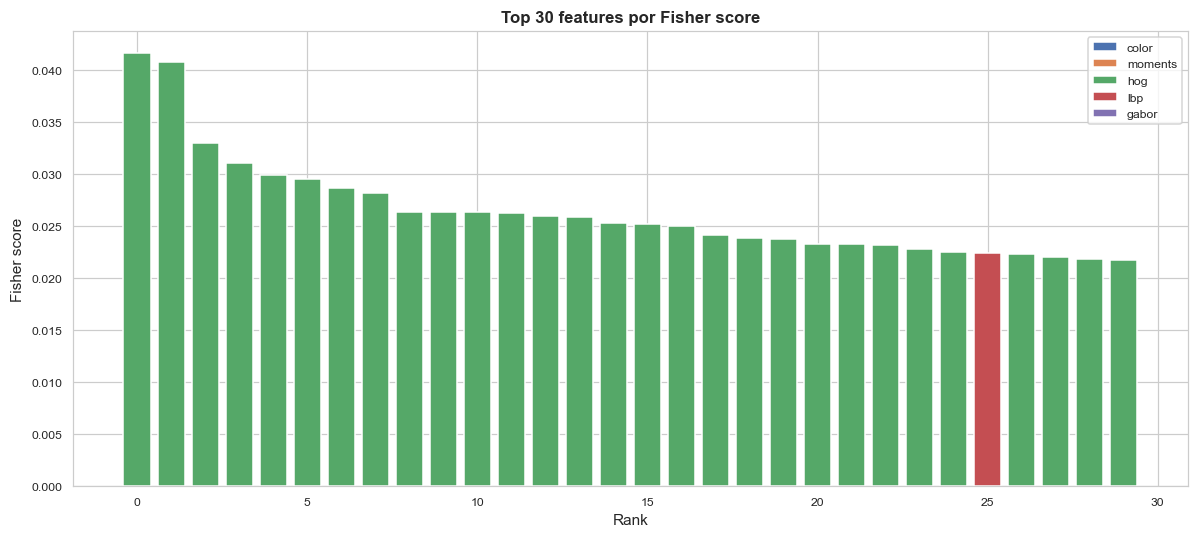


── Fisher score medio por bloque ──
  color      mean=0.0023  max=0.0095
  moments    mean=0.0040  max=0.0097
  hog        mean=0.0061  max=0.0417
  lbp        mean=0.0114  max=0.0225
  gabor      mean=0.0051  max=0.0117


In [13]:
def fisher_score(X, y):
    """Fisher score por feature."""
    classes = np.unique(y)
    mu_total = X.mean(axis=0)
    num = np.zeros(X.shape[1])
    den = np.zeros(X.shape[1])
    for c in classes:
        Xc = X[y == c]
        n  = len(Xc)
        mu = Xc.mean(axis=0)
        var = Xc.var(axis=0)
        num += n * (mu - mu_total) ** 2
        den += n * var
    return num / (den + 1e-9)

fisher = fisher_score(X_train_sc, y_train)

# Top features por bloque
fig, ax = plt.subplots(figsize=(11, 5))
top_k = 30
top_idx = np.argsort(fisher)[::-1][:top_k]

# Determinar de qué bloque es cada feature
def which_block(idx):
    for k, (a, b) in offsets.items():
        if a <= idx < b:
            return k
    return 'unk'

colors_bars = [colors_block[['color','moments','hog','lbp','gabor'].index(which_block(i))]
               for i in top_idx]
ax.bar(range(top_k), fisher[top_idx], color=colors_bars, edgecolor='white')
ax.set_title(f'Top {top_k} features por Fisher score', fontweight='bold')
ax.set_xlabel('Rank'); ax.set_ylabel('Fisher score')

leyenda = [Patch(facecolor=c, label=k)
           for c, k in zip(colors_block, ['color','moments','hog','lbp','gabor'])]
ax.legend(handles=leyenda, fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_fisher_score.png', bbox_inches='tight')
plt.show()

# Fisher agregado por bloque
print('\n── Fisher score medio por bloque ──')
for k, (a, b) in offsets.items():
    print(f'  {k:<10} mean={fisher[a:b].mean():.4f}  max={fisher[a:b].max():.4f}')


---
# BLOQUE 3 — Modelos base


<a id='10'></a>
## 10. Baselines

Todo modelo real debe superar claramente estos baselines. Si no los supera, las features no tienen señal suficiente.


In [14]:
# Diccionario global de resultados
resultados = {}

def evaluar(nombre, modelo, X_tr, y_tr, X_v, y_v, fit=True, desc=''):
    """Ajusta y evalúa un modelo en validación; guarda en `resultados`."""
    t0 = time.time()
    if fit:
        modelo.fit(X_tr, y_tr)
    t_fit = time.time() - t0

    t1 = time.time()
    y_pred = modelo.predict(X_v)
    t_pred = time.time() - t1

    # Probabilidades si están disponibles
    y_proba = None
    if hasattr(modelo, 'predict_proba'):
        try: y_proba = modelo.predict_proba(X_v)
        except Exception: pass

    resultados[nombre] = {
        'modelo': modelo,
        'accuracy':     accuracy_score(y_v, y_pred),
        'f1_macro':     f1_score(y_v, y_pred, average='macro', zero_division=0),
        'f1_weighted':  f1_score(y_v, y_pred, average='weighted', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_v, y_pred),
        'kappa':        cohen_kappa_score(y_v, y_pred),
        'mcc':          matthews_corrcoef(y_v, y_pred),
        'tiempo_fit':   t_fit,
        'tiempo_pred':  t_pred,
        'y_pred':       y_pred,
        'y_proba':      y_proba,
        'desc':         desc,
    }
    print(f'  [{nombre:<35}]  F1m={resultados[nombre]["f1_macro"]:.3f}  '
          f'BalAcc={resultados[nombre]["balanced_acc"]:.3f}  '
          f'κ={resultados[nombre]["kappa"]:.3f}  '
          f'(fit: {t_fit:5.1f}s, pred: {t_pred:.2f}s)')
    return y_pred


print('BASELINES:')
print('─' * 80)
evaluar('Baseline — Mayoría',   DummyClassifier(strategy='most_frequent', random_state=SEED),
        X_train_sc, y_train, X_val_sc, y_val,
        desc='Predice siempre la clase más frecuente')
evaluar('Baseline — Aleatorio', DummyClassifier(strategy='stratified', random_state=SEED),
        X_train_sc, y_train, X_val_sc, y_val,
        desc='Predice según proporciones del train')
evaluar('Baseline — Uniforme',  DummyClassifier(strategy='uniform', random_state=SEED),
        X_train_sc, y_train, X_val_sc, y_val,
        desc='Predice clases con probabilidad uniforme')


BASELINES:
────────────────────────────────────────────────────────────────────────────────
  [Baseline — Mayoría                 ]  F1m=0.134  BalAcc=0.200  κ=0.000  (fit:   0.0s, pred: 0.00s)
  [Baseline — Aleatorio               ]  F1m=0.204  BalAcc=0.204  κ=-0.002  (fit:   0.0s, pred: 0.00s)
  [Baseline — Uniforme                ]  F1m=0.166  BalAcc=0.189  κ=-0.016  (fit:   0.0s, pred: 0.00s)


array([3, 4, 2, ..., 2, 1, 0], dtype=int32)

<a id='11'></a>
## 11. Familia de modelos base

Entrenamos **ocho familias de modelos** (si están disponibles):

1. **Logistic Regression** — lineal, rápido, baseline fuerte
2. **SVM RBF** — kernel no lineal, muy usado
3. **Random Forest** — ensemble de árboles con bagging
4. **Extra Trees** — variante más rápida de RF con splits aleatorios
5. **Gradient Boosting** — boosting secuencial
6. **XGBoost** — boosting optimizado (si disponible)
7. **LightGBM** — boosting por histogramas (si disponible)
8. **KNN** — no paramétrico, sensible a la métrica

Todos con `class_weight='balanced'` donde sea soportado.


In [16]:
print('MODELOS BASE:')
print('─' * 80)

# 1. Logistic Regression (lineal)
lr_base = LogisticRegression(
    max_iter=3000, C=1.0, class_weight='balanced',
    multi_class='multinomial', solver='lbfgs',
    n_jobs=1, random_state=SEED
)
evaluar('Logistic Regression', lr_base, X_train_sc, y_train, X_val_sc, y_val,
        desc='L2, C=1, multinomial, balanced')

# 2. SVM RBF (usa PCA para acelerar)
svm_base = SVC(
    kernel='rbf', C=10.0, gamma='scale',
    class_weight='balanced', decision_function_shape='ovr',
    probability=True, random_state=SEED, cache_size=1000
)
evaluar('SVM RBF', svm_base, X_train_pca, y_train, X_val_pca, y_val,
        desc='RBF, C=10, gamma=scale, PCA 95% + balanced')

# 3. Random Forest
rf_base = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED
)
evaluar('Random Forest', rf_base, X_train_sc, y_train, X_val_sc, y_val,
        desc='300 trees, sqrt features, balanced')

# 4. Extra Trees
et_base = ExtraTreesClassifier(
    n_estimators=300, max_depth=None, min_samples_leaf=2,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=SEED
)
evaluar('Extra Trees', et_base, X_train_sc, y_train, X_val_sc, y_val,
        desc='300 trees, splits aleatorios, balanced')

# 5. Gradient Boosting (sklearn)
gb_base = GradientBoostingClassifier(
    n_estimators=150, learning_rate=0.1, max_depth=4,
    subsample=0.8, max_features='sqrt', random_state=SEED
)
evaluar('Gradient Boosting', gb_base, X_train_pca, y_train, X_val_pca, y_val,
        desc='150 trees, lr=0.1, depth=4, PCA 95%')

# 6. XGBoost
if HAS_XGB:
    # Sample weights para balanceo (XGBoost no tiene class_weight nativo en multiclass)
    from sklearn.utils.class_weight import compute_sample_weight
    sw = compute_sample_weight('balanced', y_train)
    xgb_base = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', num_class=len(CLASES),
        tree_method='hist', random_state=SEED, n_jobs=-1, verbosity=0
    )
    xgb_base.fit(X_train_sc, y_train, sample_weight=sw)
    evaluar('XGBoost', xgb_base, X_train_sc, y_train, X_val_sc, y_val,
            fit=False, desc='300 trees, hist, balanced sample_weight')

# 7. LightGBM
if HAS_LGB:
    lgb_base = lgb.LGBMClassifier(
        n_estimators=300, max_depth=-1, num_leaves=31,
        learning_rate=0.1, subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', objective='multiclass',
        num_class=len(CLASES), random_state=SEED, n_jobs=-1, verbose=-1
    )
    evaluar('LightGBM', lgb_base, X_train_sc, y_train, X_val_sc, y_val,
            desc='300 trees, 31 leaves, balanced')

# 8. KNN
knn_base = KNeighborsClassifier(
    n_neighbors=15, weights='distance', metric='minkowski', p=2, n_jobs=-1
)
evaluar('KNN', knn_base, X_train_pca, y_train, X_val_pca, y_val,
        desc='k=15, distance-weighted, Euclidean, PCA 95%')


MODELOS BASE:
────────────────────────────────────────────────────────────────────────────────
  [Logistic Regression                ]  F1m=0.337  BalAcc=0.349  κ=0.182  (fit:  10.9s, pred: 0.00s)
  [SVM RBF                            ]  F1m=0.499  BalAcc=0.477  κ=0.402  (fit:  26.9s, pred: 0.93s)
  [Random Forest                      ]  F1m=0.293  BalAcc=0.289  κ=0.175  (fit:   6.1s, pred: 0.03s)
  [Extra Trees                        ]  F1m=0.351  BalAcc=0.329  κ=0.232  (fit:   1.6s, pred: 0.04s)
  [Gradient Boosting                  ]  F1m=0.260  BalAcc=0.268  κ=0.140  (fit:  18.5s, pred: 0.01s)
  [XGBoost                            ]  F1m=0.439  BalAcc=0.407  κ=0.345  (fit:   0.0s, pred: 0.01s)
  [LightGBM                           ]  F1m=0.432  BalAcc=0.399  κ=0.340  (fit:  55.5s, pred: 0.04s)
  [KNN                                ]  F1m=0.377  BalAcc=0.358  κ=0.272  (fit:   0.0s, pred: 0.16s)


array([4, 4, 1, ..., 4, 4, 1], dtype=int32)

<a id='12'></a>
## 12. Validación cruzada estratificada POR GRUPO

Importante: si uso CV normal dentro de train, puede pasar que imágenes del mismo medicamento caigan en el fold de validación y en el de entrenamiento → **leakage dentro del CV**. Uso `StratifiedGroupKFold` para que un `nregistro` nunca aparezca en dos folds.

Esto nos da una **estimación más honesta** de F1-macro y nos permite elegir entre modelos con un método más robusto que un solo val set.


In [17]:
print('Cross-validation estratificada por GRUPO (nregistro)')
print('─' * 80)

cv_group = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

# Modelos a evaluar con CV (los más representativos)
modelos_cv = {
    'Logistic Regression': (lr_base, X_train_sc),
    'Random Forest':       (rf_base, X_train_sc),
    'Extra Trees':         (et_base, X_train_sc),
    'SVM RBF':             (svm_base, X_train_pca),
    'KNN':                 (knn_base, X_train_pca),
}
if HAS_LGB: modelos_cv['LightGBM'] = (lgb_base, X_train_sc)

cv_results = {}
for nombre, (mdl, X_use) in modelos_cv.items():
    t0 = time.time()
    scores = cross_val_score(
        mdl, X_use, y_train, groups=groups_train,
        cv=cv_group, scoring='f1_macro', n_jobs=-1
    )
    elapsed = time.time() - t0
    cv_results[nombre] = {
        'scores': scores,
        'mean':   scores.mean(),
        'std':    scores.std(),
        'time':   elapsed
    }
    print(f'  [{nombre:<22}]  F1m = {scores.mean():.3f} ± {scores.std():.3f}  '
          f'({elapsed:.0f}s)')

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
nombres = list(cv_results.keys())
medias = [cv_results[n]['mean'] for n in nombres]
stds   = [cv_results[n]['std']  for n in nombres]
x = np.arange(len(nombres))
ax.bar(x, medias, yerr=stds, capsize=5,
       color='#4C72B0', edgecolor='white', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=20, ha='right')
ax.set_ylabel('F1-macro (CV)')
ax.set_title('F1-macro en 5-fold StratifiedGroupKFold (train only)',
             fontweight='bold')
for xi, m, s in zip(x, medias, stds):
    ax.text(xi, m + s + 0.005, f'{m:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_cv_grouped.png', bbox_inches='tight')
plt.show()


Cross-validation estratificada por GRUPO (nregistro)
────────────────────────────────────────────────────────────────────────────────


/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssist-AI-IMAGE/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/merybri/Library/CloudStorage/OneDrive-UPNA/master_clases/segundo semestre/analisis de datos no estructurados/proyecto_imagen/MedAssis

  [Logistic Regression   ]  F1m = 0.366 ± 0.014  (12s)
  [Random Forest         ]  F1m = 0.332 ± 0.025  (36s)
  [Random Forest         ]  F1m = 0.332 ± 0.025  (36s)
  [Extra Trees           ]  F1m = 0.391 ± 0.016  (12s)
  [Extra Trees           ]  F1m = 0.391 ± 0.016  (12s)
  [SVM RBF               ]  F1m = 0.538 ± 0.020  (59s)
  [SVM RBF               ]  F1m = 0.538 ± 0.020  (59s)
  [KNN                   ]  F1m = 0.416 ± 0.022  (1s)
  [KNN                   ]  F1m = 0.416 ± 0.022  (1s)


TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

---
# BLOQUE 4 — Optimización de hiperparámetros

Tres estrategias complementarias:
- **GridSearchCV** (Random Forest) — búsqueda exhaustiva
- **RandomizedSearchCV** (SVM) — muestreo aleatorio en rangos continuos
- **HalvingRandomSearch / Optuna** (LightGBM o GB) — optimización bayesiana/sucesiva más eficiente

Todas usan `StratifiedGroupKFold` como CV para ser consistentes.


<a id='13'></a>
## 13. GridSearchCV — Random Forest


In [ ]:
param_grid_rf = {
    'n_estimators':    [200, 400, 600],
    'max_depth':       [None, 20, 40],
    'min_samples_leaf':[1, 2, 5],
    'max_features':    ['sqrt', 'log2'],
}

rf_gs = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=SEED),
    param_grid=param_grid_rf,
    scoring='f1_macro',
    cv=cv_group,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

print(f'GridSearchCV RF: {3*3*3*2} combinaciones × 5 folds = {3*3*3*2*5} fits')
t0 = time.time()
rf_gs.fit(X_train_sc, y_train, groups=groups_train)
print(f'Tiempo: {time.time()-t0:.0f}s')
print(f'\nMejores params: {rf_gs.best_params_}')
print(f'F1-macro CV: {rf_gs.best_score_:.4f}')

evaluar('Random Forest ★', rf_gs.best_estimator_,
        X_train_sc, y_train, X_val_sc, y_val, fit=False,
        desc=f'Grid optim: {rf_gs.best_params_}')

joblib.dump(rf_gs.best_estimator_, OUTPUT_DIR / 'rf_optim.pkl')


<a id='14'></a>
## 14. RandomizedSearchCV — SVM

Para SVM, `C` y `gamma` son continuos → Random Search con distribuciones log-uniformes es mucho más eficiente que Grid.


In [ ]:
param_dist_svm = {
    'C':     loguniform(0.1, 1000),
    'gamma': loguniform(1e-4, 1.0),
    'kernel': ['rbf'],  # poly suele ser mucho más lento sin mejorar
}

svm_rs = RandomizedSearchCV(
    SVC(class_weight='balanced', probability=True,
        decision_function_shape='ovr', random_state=SEED, cache_size=1000),
    param_distributions=param_dist_svm,
    n_iter=20, scoring='f1_macro',
    cv=cv_group, n_jobs=-1, verbose=0,
    random_state=SEED, refit=True
)

print('RandomizedSearchCV SVM: 20 iter × 5 folds = 100 fits')
t0 = time.time()
svm_rs.fit(X_train_pca, y_train, groups=groups_train)
print(f'Tiempo: {time.time()-t0:.0f}s')
print(f'\nMejores params: {svm_rs.best_params_}')
print(f'F1-macro CV: {svm_rs.best_score_:.4f}')

evaluar('SVM RBF ★', svm_rs.best_estimator_,
        X_train_pca, y_train, X_val_pca, y_val, fit=False,
        desc=f'Random optim: {svm_rs.best_params_}')

joblib.dump(svm_rs.best_estimator_, OUTPUT_DIR / 'svm_optim.pkl')


<a id='15'></a>
## 15. Optuna (opcional) — LightGBM / Gradient Boosting

Optuna usa TPE (Tree-structured Parzen Estimator), una optimización bayesiana mucho más eficiente que random en espacios grandes.


In [ ]:
# Solo si Optuna está disponible
if HAS_OPTUNA and HAS_LGB:
    def objective(trial):
        params = {
            'n_estimators':     trial.suggest_int('n_estimators', 100, 500),
            'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
            'max_depth':        trial.suggest_int('max_depth', 3, 12),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        }
        mdl = lgb.LGBMClassifier(
            **params, class_weight='balanced', objective='multiclass',
            num_class=len(CLASES), random_state=SEED, n_jobs=-1, verbose=-1
        )
        scores = cross_val_score(
            mdl, X_train_sc, y_train, groups=groups_train,
            cv=cv_group, scoring='f1_macro', n_jobs=-1
        )
        return scores.mean()

    print('Optuna — LightGBM (30 trials)...')
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
    t0 = time.time()
    study.optimize(objective, n_trials=30, show_progress_bar=True)
    print(f'Tiempo: {time.time()-t0:.0f}s')
    print(f'\nMejor F1-macro CV: {study.best_value:.4f}')
    print(f'Mejores params: {study.best_params}')

    # Entrenar modelo final
    lgb_optim = lgb.LGBMClassifier(
        **study.best_params, class_weight='balanced', objective='multiclass',
        num_class=len(CLASES), random_state=SEED, n_jobs=-1, verbose=-1
    )
    evaluar('LightGBM ★ (Optuna)', lgb_optim, X_train_sc, y_train, X_val_sc, y_val,
            desc=f'Optuna: {study.best_params}')
    joblib.dump(lgb_optim, OUTPUT_DIR / 'lgb_optim.pkl')

elif HAS_LGB:
    # Fallback: HalvingRandomSearch (no requiere optuna)
    from sklearn.experimental import enable_halving_search_cv  # noqa
    print('HalvingRandomSearchCV — LightGBM...')
    param_dist_lgb = {
        'n_estimators':     randint(100, 500),
        'num_leaves':       randint(15, 127),
        'max_depth':        randint(3, 12),
        'learning_rate':    loguniform(0.01, 0.3),
        'subsample':        uniform(0.6, 0.4),
        'colsample_bytree': uniform(0.6, 0.4),
    }
    lgb_hs = HalvingRandomSearchCV(
        lgb.LGBMClassifier(class_weight='balanced', objective='multiclass',
                           num_class=len(CLASES), random_state=SEED, n_jobs=-1, verbose=-1),
        param_distributions=param_dist_lgb,
        n_candidates=40, factor=3, scoring='f1_macro',
        cv=cv_group, n_jobs=-1, random_state=SEED, refit=True
    )
    t0 = time.time()
    lgb_hs.fit(X_train_sc, y_train, groups=groups_train)
    print(f'Tiempo: {time.time()-t0:.0f}s | Mejor CV: {lgb_hs.best_score_:.4f}')
    evaluar('LightGBM ★', lgb_hs.best_estimator_, X_train_sc, y_train, X_val_sc, y_val,
            fit=False, desc=f'Halving: {lgb_hs.best_params_}')
    joblib.dump(lgb_hs.best_estimator_, OUTPUT_DIR / 'lgb_optim.pkl')
else:
    print('LightGBM no disponible. Saltando optimización avanzada.')


---
# BLOQUE 5 — Ensembles


<a id='16'></a>
## 16. Voting Classifier (hard y soft)

- **Hard voting**: cada modelo vota una clase, gana la mayoría.
- **Soft voting**: se promedia la probabilidad de cada clase entre modelos y se escoge la máxima. Suele ser mejor cuando los modelos están bien calibrados.


In [ ]:
# Construimos pipelines para que cada modelo reciba su propio preprocesamiento
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=3000, C=1.0, class_weight='balanced',
                                   multi_class='multinomial', n_jobs=1, random_state=SEED))
])
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(**rf_gs.best_params_,
                                       class_weight='balanced', n_jobs=-1, random_state=SEED))
])
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca',    PCA(n_components=n_comp_95, random_state=SEED)),
    ('clf',    SVC(**svm_rs.best_params_, class_weight='balanced',
                   probability=True, decision_function_shape='ovr',
                   random_state=SEED, cache_size=1000))
])

estimators = [('lr', pipe_lr), ('rf', pipe_rf), ('svm', pipe_svm)]
if HAS_LGB:
    pipe_lgb = Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    joblib.load(OUTPUT_DIR / 'lgb_optim.pkl'))
    ])
    estimators.append(('lgb', pipe_lgb))

# Soft voting
voting_soft = VotingClassifier(estimators=estimators, voting='soft', n_jobs=-1)
evaluar('Voting Soft', voting_soft, X_train, y_train, X_val, y_val,
        desc='LR + RF + SVM' + (' + LGB' if HAS_LGB else ''))

# Hard voting
voting_hard = VotingClassifier(estimators=estimators, voting='hard', n_jobs=-1)
evaluar('Voting Hard', voting_hard, X_train, y_train, X_val, y_val,
        desc='LR + RF + SVM' + (' + LGB' if HAS_LGB else ''))


<a id='17'></a>
## 17. Stacking con meta-learner

En **stacking** entrenamos un modelo "meta" (Logistic Regression) que aprende a combinar las probabilidades de los modelos base. Más potente que voting pero más propenso a overfitting si el meta-learner es complejo.


In [ ]:
stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(
        max_iter=3000, C=1.0, class_weight='balanced',
        multi_class='multinomial', random_state=SEED
    ),
    cv=5,          # CV interno para generar las predicciones que alimentan el meta
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=False,   # True añadiría features originales al meta (más riesgo overfit)
)

evaluar('Stacking (meta=LR)', stacking, X_train, y_train, X_val, y_val,
        desc='Base: LR+RF+SVM(+LGB) | Meta: LR con CV=5')


---
# BLOQUE 6 — Ablation studies

Los ablation studies son lo que separa un trabajo "bueno" de un trabajo "excelente". Responden a la pregunta: **¿cuál es el impacto real de cada decisión de diseño?**

Vamos a hacer tres:
1. **Con vs sin augmentation offline** (¿vale la pena balancear por augmentation?)
2. **Tres estrategias de balanceo** (augmentation vs class_weight vs ninguna)
3. **Importancia de cada bloque de features** (¿puedo quitar Gabor y rendir igual?)

Usamos **Random Forest** como modelo pivote porque es robusto, no necesita tuning fino y es rápido.


<a id='18'></a>
## 18. Ablation 1: con vs sin augmentation offline

Entrenamos el mismo modelo (RF con los mejores hiperparámetros) sobre:
- **A)** Train completo (originales + aumentadas)
- **B)** Train solo con originales

Comparamos F1-macro en el **mismo val set** (val es idéntico: no tiene aug).


In [ ]:
# Máscaras para train con/sin aug
mask_only_orig = ~is_aug_train

X_train_orig = X_train_sc[mask_only_orig]
y_train_orig = y_train[mask_only_orig]

print(f'Train completo (orig + aug): {X_train_sc.shape[0]:,}')
print(f'Train solo originales:        {X_train_orig.shape[0]:,}')
print()

rf_params = rf_gs.best_params_

# A) Con augmentation offline
mdl_con_aug = RandomForestClassifier(
    **rf_params, class_weight='balanced', n_jobs=-1, random_state=SEED
)
evaluar('Ablation 1 — CON aug offline', mdl_con_aug,
        X_train_sc, y_train, X_val_sc, y_val,
        desc='Train: originales + sintéticas (balanceado)')

# B) Sin augmentation offline
mdl_sin_aug = RandomForestClassifier(
    **rf_params, class_weight='balanced', n_jobs=-1, random_state=SEED
)
evaluar('Ablation 1 — SIN aug offline', mdl_sin_aug,
        X_train_orig, y_train_orig, X_val_sc, y_val,
        desc='Train: solo originales (desbalanceado, class_weight compensa)')

# Visualización comparativa
f1_con = resultados['Ablation 1 — CON aug offline']['f1_macro']
f1_sin = resultados['Ablation 1 — SIN aug offline']['f1_macro']
ba_con = resultados['Ablation 1 — CON aug offline']['balanced_acc']
ba_sin = resultados['Ablation 1 — SIN aug offline']['balanced_acc']

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(2); w = 0.35
ax.bar(x - w/2, [f1_con, f1_sin], w, color='#4C72B0', label='F1-macro', edgecolor='white')
ax.bar(x + w/2, [ba_con, ba_sin], w, color='#DD8452', label='Balanced Acc', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['CON aug offline\n(train ' + f'{X_train_sc.shape[0]:,})',
                    'SIN aug offline\n(train ' + f'{X_train_orig.shape[0]:,})'])
for xi, v in zip([0,1], [f1_con, f1_sin]):
    ax.text(xi - w/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
for xi, v in zip([0,1], [ba_con, ba_sin]):
    ax.text(xi + w/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(); ax.set_ylabel('Score')
ax.set_title('Ablation 1: efecto del augmentation offline', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation_aug.png', bbox_inches='tight')
plt.show()

delta = f1_con - f1_sin
print(f'\nΔ F1-macro = {delta:+.4f}')
if delta > 0.01:
    print('→ El augmentation offline APORTA valor (> +0.01 F1).')
elif delta > -0.01:
    print('→ Efecto neutro: el class_weight basta para compensar el desbalance.')
else:
    print('→ El augmentation está introduciendo ruido. Revisa los pipelines.')


<a id='19'></a>
## 19. Ablation 2: estrategias de balanceo

Tres estrategias sobre **el mismo conjunto de originales** (sin augmentation offline):
- **A)** Sin balanceo (modelo ignora desbalance)
- **B)** `class_weight='balanced'`
- **C)** Oversampling aleatorio (replicar minoritarias hasta igualar mayoritaria)


In [ ]:
from collections import Counter

# A) Sin balanceo
mdl_a = RandomForestClassifier(**rf_params, n_jobs=-1, random_state=SEED)
evaluar('Ablation 2 — Sin balanceo', mdl_a,
        X_train_orig, y_train_orig, X_val_sc, y_val,
        desc='Sin augmentation, sin class_weight')

# B) class_weight='balanced'
mdl_b = RandomForestClassifier(**rf_params, class_weight='balanced',
                                n_jobs=-1, random_state=SEED)
evaluar('Ablation 2 — class_weight=balanced', mdl_b,
        X_train_orig, y_train_orig, X_val_sc, y_val,
        desc='Sin augmentation, class_weight=balanced')

# C) Oversampling manual
def random_oversample(X, y, seed=SEED):
    rng = np.random.default_rng(seed)
    counts = Counter(y)
    n_max  = max(counts.values())
    X_new, y_new = [X], [y]
    for cls, n in counts.items():
        if n < n_max:
            idx = np.where(y == cls)[0]
            picks = rng.choice(idx, n_max - n, replace=True)
            X_new.append(X[picks]); y_new.append(y[picks])
    return np.vstack(X_new), np.concatenate(y_new)

X_over, y_over = random_oversample(X_train_orig, y_train_orig)
print(f'  Oversampling: {X_train_orig.shape[0]:,} → {X_over.shape[0]:,}')

mdl_c = RandomForestClassifier(**rf_params, n_jobs=-1, random_state=SEED)
evaluar('Ablation 2 — Random Oversampling', mdl_c,
        X_over, y_over, X_val_sc, y_val,
        desc='Sin augmentation, duplicación aleatoria')

# Visualización
labels = ['Sin balanceo', 'class_weight', 'Oversampling']
f1s = [resultados[f'Ablation 2 — {"Sin balanceo" if i==0 else "class_weight=balanced" if i==1 else "Random Oversampling"}']['f1_macro']
       for i in range(3)]
bas = [resultados[f'Ablation 2 — {"Sin balanceo" if i==0 else "class_weight=balanced" if i==1 else "Random Oversampling"}']['balanced_acc']
       for i in range(3)]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, f1s, w, color='#4C72B0', label='F1-macro', edgecolor='white')
ax.bar(x + w/2, bas, w, color='#DD8452', label='Balanced Acc', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(labels)
for xi, v in zip(x, f1s):
    ax.text(xi - w/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
for xi, v in zip(x, bas):
    ax.text(xi + w/2, v + 0.003, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.legend(); ax.set_ylabel('Score')
ax.set_title('Ablation 2: estrategia de balanceo (sin augmentation offline)',
             fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation_balanceo.png', bbox_inches='tight')
plt.show()


<a id='20'></a>
## 20. Ablation 3: importancia de cada bloque de features

Entrenamos el mismo RF quitando un bloque de features cada vez. Si quitar un bloque no degrada el F1, ese bloque es redundante.


In [ ]:
all_blocks = ['color', 'moments', 'hog', 'lbp', 'gabor']

# Entrenar con TODOS
def build_X(feats, blocks):
    return np.concatenate([feats['blocks'][k] for k in blocks], axis=1)

resultados_abl3 = {}

# All blocks
X_tr_all = build_X(feats_train, all_blocks)
X_vl_all = build_X(feats_val,   all_blocks)
sc_all   = StandardScaler().fit(X_tr_all)
mdl_all  = RandomForestClassifier(**rf_params, class_weight='balanced',
                                   n_jobs=-1, random_state=SEED)
mdl_all.fit(sc_all.transform(X_tr_all), y_train)
f1_all = f1_score(y_val, mdl_all.predict(sc_all.transform(X_vl_all)),
                  average='macro', zero_division=0)
resultados_abl3['ALL'] = f1_all
print(f'  ALL blocks:          F1m = {f1_all:.4f}  (dims: {X_tr_all.shape[1]})')

# Leave-one-out
for drop in all_blocks:
    use = [b for b in all_blocks if b != drop]
    X_tr = build_X(feats_train, use)
    X_vl = build_X(feats_val,   use)
    sc   = StandardScaler().fit(X_tr)
    mdl  = RandomForestClassifier(**rf_params, class_weight='balanced',
                                   n_jobs=-1, random_state=SEED)
    mdl.fit(sc.transform(X_tr), y_train)
    f1 = f1_score(y_val, mdl.predict(sc.transform(X_vl)),
                  average='macro', zero_division=0)
    resultados_abl3[f'-{drop}'] = f1
    delta = f1 - f1_all
    print(f'  sin {drop:<8}:      F1m = {f1:.4f}  Δ={delta:+.4f}  '
          f'(dims: {X_tr.shape[1]})')

# Solo un bloque
for keep in all_blocks:
    X_tr = build_X(feats_train, [keep])
    X_vl = build_X(feats_val,   [keep])
    sc   = StandardScaler().fit(X_tr)
    mdl  = RandomForestClassifier(**rf_params, class_weight='balanced',
                                   n_jobs=-1, random_state=SEED)
    mdl.fit(sc.transform(X_tr), y_train)
    f1 = f1_score(y_val, mdl.predict(sc.transform(X_vl)),
                  average='macro', zero_division=0)
    resultados_abl3[f'only_{keep}'] = f1
    print(f'  SOLO {keep:<8}:     F1m = {f1:.4f}  '
          f'(dims: {X_tr.shape[1]})')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Leave-one-out
drops = [k for k in resultados_abl3 if k.startswith('-')]
deltas = [resultados_abl3[k] - f1_all for k in drops]
colors = ['#C44E52' if d < 0 else '#55A868' for d in deltas]
axes[0].barh([k.replace('-','sin ') for k in drops], deltas,
             color=colors, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Ablation: Δ F1-macro al QUITAR un bloque', fontweight='bold')
axes[0].set_xlabel('Δ F1-macro (negativo = el bloque aporta)')
for i, d in enumerate(deltas):
    axes[0].text(d + (0.001 if d >= 0 else -0.001), i, f'{d:+.4f}',
                 va='center', ha='left' if d >= 0 else 'right', fontsize=8)

# Solo un bloque
keeps = [k for k in resultados_abl3 if k.startswith('only_')]
f1s   = [resultados_abl3[k] for k in keeps]
axes[1].barh([k.replace('only_','solo ') for k in keeps], f1s,
             color='#4C72B0', edgecolor='white')
axes[1].axvline(f1_all, color='#C44E52', ls='--', label=f'Todos: {f1_all:.3f}')
axes[1].set_title('F1-macro con un SOLO bloque', fontweight='bold')
axes[1].set_xlabel('F1-macro')
axes[1].legend()
for i, v in enumerate(f1s):
    axes[1].text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_ablation_features.png', bbox_inches='tight')
plt.show()


---
# BLOQUE 7 — Evaluación exhaustiva


<a id='21'></a>
## 21. Curvas ROC, PR y calibración

### Reliability diagram
Un modelo está **bien calibrado** si cuando predice 0.8 de probabilidad, acierta el 80% de las veces. Modelos como RF tienden a ser sobreconfiantes → reliability diagram lo visualiza.


In [ ]:
# Seleccionar el mejor modelo no-ensemble
modelos_no_dummy = {k: v for k, v in resultados.items() if 'Baseline' not in k
                    and 'Ablation' not in k}
mejor_nombre = max(modelos_no_dummy, key=lambda k: modelos_no_dummy[k]['f1_macro'])
mejor = modelos_no_dummy[mejor_nombre]
print(f'Mejor modelo: {mejor_nombre}  (F1-macro val = {mejor["f1_macro"]:.4f})')

y_proba = mejor['y_proba']
y_pred  = mejor['y_pred']

# ── Classification report ────────────────────────────────────────────────────
print('\n── CLASSIFICATION REPORT (val) ──')
print(classification_report(y_val, y_pred, target_names=le.classes_, digits=4))

# ── Curvas ROC y PR ──────────────────────────────────────────────────────────
y_val_bin = label_binarize(y_val, classes=range(len(CLASES)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

if y_proba is not None:
    # ROC
    for i, cls in enumerate(CLASES):
        fpr, tpr, _ = roc_curve(y_val_bin[:, i], y_proba[:, i])
        roc_auc_val = auc(fpr, tpr)
        axes[0].plot(fpr, tpr, color=PALETTE[cls], lw=2,
                     label=f'{cls[:24]} (AUC={roc_auc_val:.3f})')
    axes[0].plot([0,1],[0,1],'k--',lw=1)
    axes[0].set_title(f'ROC OvR — {mejor_nombre}', fontweight='bold')
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].legend(fontsize=7)

    # PR
    for i, cls in enumerate(CLASES):
        prec, rec, _ = precision_recall_curve(y_val_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_val_bin[:, i], y_proba[:, i])
        axes[1].plot(rec, prec, color=PALETTE[cls], lw=2,
                     label=f'{cls[:24]} (AP={ap:.3f})')
    axes[1].set_title(f'Precision-Recall OvR — {mejor_nombre}', fontweight='bold')
    axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
    axes[1].legend(fontsize=7)

    # Reliability diagram (multi-clase: promediamos por clase)
    for i, cls in enumerate(CLASES):
        frac_pos, mean_pred = calibration_curve(
            y_val_bin[:, i], y_proba[:, i], n_bins=10, strategy='quantile'
        )
        axes[2].plot(mean_pred, frac_pos, 'o-', color=PALETTE[cls],
                     label=cls[:24], markersize=5)
    axes[2].plot([0,1],[0,1],'k--',lw=1, label='Perfecta')
    axes[2].set_title(f'Reliability diagram — {mejor_nombre}', fontweight='bold')
    axes[2].set_xlabel('Probabilidad media predicha')
    axes[2].set_ylabel('Fracción de positivos')
    axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_roc_pr_calib.png', bbox_inches='tight')
plt.show()

# Brier score y log-loss
if y_proba is not None:
    brier = np.mean([brier_score_loss(y_val_bin[:,i], y_proba[:,i])
                     for i in range(len(CLASES))])
    ll = log_loss(y_val, y_proba)
    print(f'\n── Calibración ──')
    print(f'  Brier score (promedio OvR): {brier:.4f}  (↓ mejor)')
    print(f'  Log loss:                   {ll:.4f}  (↓ mejor)')


<a id='22'></a>
## 22. Curvas de aprendizaje

Permiten diagnosticar:
- **Alto bias** (underfitting): train y val bajos y cerca entre sí → modelo demasiado simple.
- **Alta variance** (overfitting): train alto, val mucho más bajo → modelo demasiado complejo.
- **Datos suficientes?**: si la curva de val sigue subiendo, más datos ayudarían.


In [ ]:
train_sizes = np.linspace(0.1, 1.0, 6)

# Para que sea rápido, usamos el mejor modelo (que ya está en memoria)
# o un RF razonable si el mejor es muy costoso
mdl_lc = RandomForestClassifier(**rf_params, class_weight='balanced',
                                 n_jobs=-1, random_state=SEED)

print('Calculando learning curves (puede tardar)...')
sizes, train_scores, val_scores = learning_curve(
    mdl_lc, X_train_sc, y_train, groups=groups_train,
    train_sizes=train_sizes, cv=cv_group,
    scoring='f1_macro', n_jobs=-1, random_state=SEED
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, train_scores.mean(axis=1), 'o-', color='#4C72B0',
        label='Train', linewidth=2)
ax.fill_between(sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#4C72B0')

ax.plot(sizes, val_scores.mean(axis=1), 'o-', color='#DD8452',
        label='Validation (CV)', linewidth=2)
ax.fill_between(sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#DD8452')

ax.set_xlabel('Nº de muestras de train')
ax.set_ylabel('F1-macro')
ax.set_title('Curvas de aprendizaje — Random Forest', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_learning_curves.png', bbox_inches='tight')
plt.show()

gap = train_scores.mean(axis=1)[-1] - val_scores.mean(axis=1)[-1]
print(f'\nGap train-val al 100%: {gap:.3f}')
if gap > 0.1:
    print('→ Overfitting claro: el modelo memoriza más de lo que generaliza.')
elif gap > 0.05:
    print('→ Overfitting moderado: aceptable con regularización.')
else:
    print('→ Gap pequeño: modelo bien regularizado.')


<a id='23'></a>
## 23. Test de significancia estadística (McNemar)

Cuando dos modelos tienen F1 muy similares (ej. 0.842 vs 0.847), ¿es la diferencia **real** o fruto del azar? El **McNemar test** lo responde.

Compara dos clasificadores sobre el mismo conjunto mirando la tabla:

|  | B acierta | B falla |
|---|---|---|
| A acierta | a | b |
| A falla | c | d |

Si `b ≠ c` de forma significativa → los modelos tienen comportamientos diferentes.


In [ ]:
from statsmodels.stats.contingency_tables import mcnemar
# Si statsmodels no está disponible, aproximamos manualmente
try:
    import statsmodels
    HAS_SM = True
except ImportError:
    HAS_SM = False

# Seleccionar top-2 modelos (no-dummy)
modelos_ord = sorted(modelos_no_dummy.items(),
                     key=lambda kv: kv[1]['f1_macro'], reverse=True)
top1_nombre, top1 = modelos_ord[0]
top2_nombre, top2 = modelos_ord[1]

y_pred_1 = top1['y_pred']
y_pred_2 = top2['y_pred']

# Tabla de contingencia
correct_1 = y_pred_1 == y_val
correct_2 = y_pred_2 == y_val

a = int(( correct_1 &  correct_2).sum())
b = int(( correct_1 & ~correct_2).sum())
c = int((~correct_1 &  correct_2).sum())
d = int((~correct_1 & ~correct_2).sum())

print(f'Top 1: {top1_nombre}  (F1m={top1["f1_macro"]:.4f})')
print(f'Top 2: {top2_nombre}  (F1m={top2["f1_macro"]:.4f})')
print()
print(f'  {"":30s}  Top2 ✓    Top2 ✗')
print(f'  {"Top1 ✓":30s}  {a:>6}    {b:>6}')
print(f'  {"Top1 ✗":30s}  {c:>6}    {d:>6}')

if HAS_SM:
    result = mcnemar([[a, b], [c, d]], exact=False, correction=True)
    print(f'\nMcNemar χ² statistic: {result.statistic:.3f}')
    print(f'p-value:              {result.pvalue:.4f}')
    if result.pvalue < 0.05:
        print(f'→ Diferencia ESTADÍSTICAMENTE SIGNIFICATIVA (p < 0.05).')
        print(f'  El Top 1 es genuinamente mejor que el Top 2.')
    else:
        print(f'→ Diferencia no significativa (p ≥ 0.05).')
        print(f'  Los dos modelos son equivalentes en este val set.')
else:
    # Cálculo manual con corrección de continuidad de Yates
    chi2 = (abs(b - c) - 1) ** 2 / (b + c) if (b + c) > 0 else 0
    # p-value con 1 gl
    from scipy.stats import chi2 as chi2dist
    p = 1 - chi2dist.cdf(chi2, df=1)
    print(f'\nMcNemar χ² (manual): {chi2:.3f}')
    print(f'p-value:             {p:.4f}')


<a id='24'></a>
## 24. Análisis profundo de errores

Vamos mucho más allá de la matriz de confusión: visualizamos **imágenes reales** que el modelo confunde, analizamos los errores por **nivel de confianza** y buscamos patrones.


In [ ]:
# Construir dataframe de predicciones del mejor modelo
df_val_pred = df_val.iloc[feats_val['valid_idx']].copy().reset_index(drop=True)
df_val_pred['y_real']     = le.inverse_transform(y_val)
df_val_pred['y_pred']     = le.inverse_transform(y_pred)
df_val_pred['correcto']   = df_val_pred['y_real'] == df_val_pred['y_pred']
if y_proba is not None:
    df_val_pred['confianza']  = y_proba.max(axis=1)
    # Para cada fila, la prob de la clase REAL (cuán seguro estaba el modelo de lo correcto)
    df_val_pred['prob_real']  = y_proba[np.arange(len(y_val)), y_val]

print('── Tasa de acierto ──')
print(df_val_pred.groupby('image_type')['correcto'].agg(['mean','count']).round(4).to_string())

# ── Errores más frecuentes ───────────────────────────────────────────────────
pares = (df_val_pred[~df_val_pred['correcto']]
         .groupby(['y_real','y_pred']).size()
         .sort_values(ascending=False).head(10))
print('\n── Top 10 pares de confusión ──')
print(pares.to_string())

# ── Análisis por confianza ───────────────────────────────────────────────────
if y_proba is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    # Histograma de confianza separado por correcto/error
    bins = np.linspace(0, 1, 21)
    axes[0].hist(df_val_pred[df_val_pred['correcto']]['confianza'],
                 bins=bins, alpha=0.7, color='#55A868', label='Correcto', density=True)
    axes[0].hist(df_val_pred[~df_val_pred['correcto']]['confianza'],
                 bins=bins, alpha=0.7, color='#C44E52', label='Error', density=True)
    axes[0].set_title('Distribución de confianza del modelo', fontweight='bold')
    axes[0].set_xlabel('Máx. probabilidad predicha'); axes[0].set_ylabel('Densidad')
    axes[0].legend()

    # Accuracy por bins de confianza
    df_val_pred['conf_bin'] = pd.cut(df_val_pred['confianza'],
                                      bins=np.linspace(0, 1, 11))
    acc_by_bin = df_val_pred.groupby('conf_bin')['correcto'].agg(['mean', 'count'])
    centers = [(b.left + b.right)/2 for b in acc_by_bin.index]
    axes[1].bar(centers, acc_by_bin['mean'], width=0.08,
                color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[1].plot([0,1],[0,1],'k--', alpha=0.5, label='Ideal (calibrado)')
    axes[1].set_title('Accuracy por bin de confianza\n(calibración empírica)',
                      fontweight='bold')
    axes[1].set_xlabel('Bin de confianza')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    for c, m, n in zip(centers, acc_by_bin['mean'], acc_by_bin['count']):
        if not np.isnan(m):
            axes[1].text(c, m + 0.02, f'n={int(n)}', ha='center', fontsize=7)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'ml_error_confianza.png', bbox_inches='tight')
    plt.show()


In [ ]:
# ── Visualizar errores más "seguros" (modelo muy confiado pero se equivoca) ──
# Estos son los errores más alarmantes
if y_proba is not None:
    errores_conf = (df_val_pred[~df_val_pred['correcto']]
                    .sort_values('confianza', ascending=False)
                    .head(12))

    fig, axes = plt.subplots(3, 4, figsize=(14, 10))
    axes = axes.flatten()
    for ax, (_, row) in zip(axes, errores_conf.iterrows()):
        try:
            img = Image.open(row['image_path']).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#eee')
        ax.axis('off')
        ax.set_title(f'Real: {row["y_real"][:15]}\n'
                     f'Pred: {row["y_pred"][:15]} ({row["confianza"]:.2f})',
                     fontsize=8, color='#C44E52')

    plt.suptitle(f'Errores más confiados — {mejor_nombre}\n'
                 f'(modelo muy seguro pero se equivoca)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'ml_errores_confiados.png', bbox_inches='tight')
    plt.show()


---
# BLOQUE 8 — Evaluación final en test


<a id='25'></a>
## 25. Evaluación final (una única vez)

**Regla**: test se toca una sola vez, al final, con el modelo YA elegido según val. Si evaluara varios modelos en test y eligiera el mejor, estaría haciendo data snooping.


In [ ]:
print('⚠️  EVALUACIÓN FINAL EN TEST — SOLO UNA VEZ')
print('=' * 70)

# Determinar qué X_test usar según el modelo
# (los que usan PCA necesitan X_test_pca)
nombre_mejor_final = mejor_nombre
mejor_final = mejor['modelo']

# Determinar qué transformación aplicar
# Heurística: si el pipeline del mejor usó PCA lo registramos
uses_pca = ('PCA' in mejor['desc']) or ('SVM' in nombre_mejor_final)
X_test_use = X_test_pca if uses_pca else X_test_sc
X_val_use  = X_val_pca  if uses_pca else X_val_sc

# Predicción en test
y_pred_test = mejor_final.predict(X_test_use)
y_proba_test = mejor_final.predict_proba(X_test_use) if hasattr(mejor_final, 'predict_proba') else None

acc_test   = accuracy_score(y_test, y_pred_test)
f1m_test   = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
f1w_test   = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
ba_test    = balanced_accuracy_score(y_test, y_pred_test)
kappa_test = cohen_kappa_score(y_test, y_pred_test)
mcc_test   = matthews_corrcoef(y_test, y_pred_test)

print(f'\n  Modelo: {nombre_mejor_final}')
print(f'  {"Accuracy":<18}: {acc_test:.4f}')
print(f'  {"F1-macro":<18}: {f1m_test:.4f}')
print(f'  {"F1-weighted":<18}: {f1w_test:.4f}')
print(f'  {"Balanced Acc":<18}: {ba_test:.4f}')
print(f'  {"Cohen Kappa":<18}: {kappa_test:.4f}')
print(f'  {"MCC":<18}: {mcc_test:.4f}')

print('\n── Classification report TEST ──')
print(classification_report(y_test, y_pred_test, target_names=le.classes_, digits=4))

# Matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
cm_abs  = confusion_matrix(y_test, y_pred_test)
cm_norm = confusion_matrix(y_test, y_pred_test, normalize='true')

ConfusionMatrixDisplay(cm_abs, display_labels=le.classes_).plot(
    ax=axes[0], colorbar=False, cmap='Blues', xticks_rotation=45)
axes[0].set_title('Confusion matrix — TEST (absoluta)', fontweight='bold')

ConfusionMatrixDisplay(cm_norm, display_labels=le.classes_).plot(
    ax=axes[1], colorbar=True, cmap='Blues', values_format='.2f', xticks_rotation=45)
axes[1].set_title('Confusion matrix — TEST (normalizada por fila)', fontweight='bold')

plt.suptitle(f'EVALUACIÓN FINAL — {nombre_mejor_final}', fontsize=12,
             fontweight='bold', color='#C44E52')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_confusion_TEST_FINAL.png', bbox_inches='tight')
plt.show()


<a id='26'></a>
## 26. Comparativa Val vs Test

El gap val→test indica si hemos **sobreajustado al val** durante la selección y ajuste de hiperparámetros.


In [ ]:
f1m_val = mejor['f1_macro']
acc_val = mejor['accuracy']
ba_val  = mejor['balanced_acc']
kap_val = mejor['kappa']

print(f'{"Métrica":<18} {"Val":>10} {"Test":>10} {"Δ":>10}')
print('─' * 48)
print(f'{"F1-macro":<18} {f1m_val:>10.4f} {f1m_test:>10.4f} {f1m_test-f1m_val:>+10.4f}')
print(f'{"Accuracy":<18} {acc_val:>10.4f} {acc_test:>10.4f} {acc_test-acc_val:>+10.4f}')
print(f'{"Balanced Acc":<18} {ba_val:>10.4f} {ba_test:>10.4f} {ba_test-ba_val:>+10.4f}')
print(f'{"Cohen Kappa":<18} {kap_val:>10.4f} {kappa_test:>10.4f} {kappa_test-kap_val:>+10.4f}')

delta = abs(f1m_test - f1m_val)
print()
if delta < 0.02:
    print(f'✅ Δ F1m = {delta:.3f} < 0.02 → NO hay sobreajuste al val set.')
elif delta < 0.05:
    print(f'⚠️  Δ F1m = {delta:.3f} en [0.02, 0.05] → sobreajuste moderado aceptable.')
else:
    print(f'❌ Δ F1m = {delta:.3f} > 0.05 → posible sobreajuste al proceso de selección.')

# Visualización
fig, ax = plt.subplots(figsize=(9, 4.5))
metrics = ['F1-macro', 'Accuracy', 'Bal. Acc', 'Kappa']
vals = [f1m_val, acc_val, ba_val, kap_val]
tests = [f1m_test, acc_test, ba_test, kappa_test]
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, vals,  w, color='#4C72B0', label='Val',  edgecolor='white')
ax.bar(x + w/2, tests, w, color='#DD8452', label='Test', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1); ax.set_ylabel('Score')
ax.set_title(f'Val vs Test — {nombre_mejor_final}', fontweight='bold')
ax.legend()
for xi, v, t in zip(x, vals, tests):
    ax.text(xi - w/2, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)
    ax.text(xi + w/2, t + 0.01, f'{t:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_val_vs_test.png', bbox_inches='tight')
plt.show()


<a id='27'></a>
## 27. Guardado del pipeline de producción

Guardamos como un único artefacto (`Pipeline` sklearn):
- Scaler
- PCA (si aplica)
- Modelo final

Además, un JSON con la **metadata completa** del experimento para trazabilidad.


In [ ]:
# ── Pipeline de producción (scaler + opcional PCA + modelo) ──────────────────
if uses_pca:
    pipeline_final = Pipeline([
        ('scaler', scaler),
        ('pca',    pca_95),
        ('clf',    mejor_final),
    ])
else:
    pipeline_final = Pipeline([
        ('scaler', scaler),
        ('clf',    mejor_final),
    ])

# Verificamos que el pipeline predice igual que el modelo "crudo"
# (El pipeline toma X_test crudo; el modelo tomaba X_test_use ya procesado)
y_pred_pipe = pipeline_final.predict(X_test)
consistencia = (y_pred_pipe == y_pred_test).mean()
print(f'Consistencia pipeline vs modelo raw: {consistencia*100:.2f}%')

# ── Guardar artefactos ───────────────────────────────────────────────────────
joblib.dump(pipeline_final, OUTPUT_DIR / 'pipeline_ml_final.pkl')
joblib.dump(le, OUTPUT_DIR / 'label_encoder.pkl')

# Metadata completa del experimento
metadata = {
    'experiment_version':  EXPERIMENT_VERSION,
    'timestamp':           datetime.now().isoformat(),
    'features_version':    FEATURES_VERSION,
    'best_model_name':     nombre_mejor_final,
    'best_model_desc':     mejor['desc'],
    'uses_pca':            uses_pca,
    'n_features_raw':      int(X_train.shape[1]),
    'n_features_pca':      int(n_comp_95) if uses_pca else None,
    'feature_dims':        feats_train['feature_dims'],
    'classes':             CLASES,
    'n_samples': {
        'train':           int(len(df_train)),
        'train_orig':      int((~is_aug_train).sum()),
        'train_augmented': int(is_aug_train.sum()),
        'val':             int(len(df_val)),
        'test':            int(len(df_test)),
    },
    'metrics_val': {
        'accuracy':     float(acc_val),
        'f1_macro':     float(f1m_val),
        'balanced_acc': float(ba_val),
        'kappa':        float(kap_val),
    },
    'metrics_test': {
        'accuracy':     float(acc_test),
        'f1_macro':     float(f1m_test),
        'balanced_acc': float(ba_test),
        'kappa':        float(kappa_test),
        'mcc':          float(mcc_test),
    },
    'seed':                SEED,
    'img_size':            list(IMG_SIZE),
}

with open(OUTPUT_DIR / 'experiment_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print('\n── Artefactos guardados ──')
for p in [OUTPUT_DIR / 'pipeline_ml_final.pkl',
          OUTPUT_DIR / 'label_encoder.pkl',
          OUTPUT_DIR / 'experiment_metadata.json']:
    print(f'  ✔ {p}')


---
# BLOQUE 9 — Conclusiones


<a id='28'></a>
## 28. Síntesis de resultados


In [ ]:
# Tabla comparativa completa
df_all = pd.DataFrame([
    {
        'Modelo':        n,
        'F1-macro':      r['f1_macro'],
        'Balanced Acc':  r['balanced_acc'],
        'Accuracy':      r['accuracy'],
        'Kappa':         r['kappa'],
        'MCC':           r['mcc'],
        'Fit (s)':       r['tiempo_fit'],
        'Pred (s)':      r['tiempo_pred'],
        'Descripción':   r['desc'],
    }
    for n, r in resultados.items()
]).sort_values('F1-macro', ascending=False).reset_index(drop=True)

df_all.to_csv(OUTPUT_DIR / 'comparativa_todos_modelos.csv', index=False)

print('═' * 110)
print('  COMPARATIVA FINAL — TODOS LOS MODELOS (orden por F1-macro en VAL)')
print('═' * 110)
print(df_all[['Modelo','F1-macro','Balanced Acc','Accuracy','Kappa','MCC','Fit (s)']].round(4).to_string(index=True))
print()
print(f'✔ Tabla completa guardada en {OUTPUT_DIR / "comparativa_todos_modelos.csv"}')

# Gráfico final
fig, ax = plt.subplots(figsize=(11, max(5, 0.3*len(df_all))))
df_plot = df_all[~df_all['Modelo'].str.contains('Baseline')].head(15)
nombres_cortos = [n[:40] for n in df_plot['Modelo']]
colors = ['#C44E52' if 'Ablation' in n
          else '#55A868' if '★' in n
          else '#4C72B0' for n in df_plot['Modelo']]
bars = ax.barh(nombres_cortos, df_plot['F1-macro'], color=colors, edgecolor='white')
for bar, v in zip(bars, df_plot['F1-macro']):
    ax.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.3f}',
            va='center', fontsize=8, fontweight='bold')

# Línea de baseline
baseline_f1 = df_all[df_all['Modelo'].str.contains('Baseline')]['F1-macro'].max()
ax.axvline(baseline_f1, ls='--', color='gray', alpha=0.7,
           label=f'Mejor baseline ({baseline_f1:.3f})')
ax.set_xlabel('F1-macro (val)')
ax.set_title('Comparativa final de modelos', fontweight='bold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ml_comparativa_final.png', bbox_inches='tight')
plt.show()


In [ ]:
print(f'''
╔══════════════════════════════════════════════════════════════════════════════╗
║                  RESUMEN EJECUTIVO DEL MÓDULO ML                             ║
╠══════════════════════════════════════════════════════════════════════════════╣
║
║  EXPERIMENTO: {EXPERIMENT_VERSION}
║
║  DATASET
║   · {len(df):,} imágenes  |  {df[GROUP_COL].nunique():,} medicamentos  |  {len(CLASES)} clases
║   · Split: train={len(df_train):,} (aug: {is_aug_train.sum():,}) / val={len(df_val):,} / test={len(df_test):,}
║   · Sin data leakage: verificado por nregistro y por augmentación sólo en train
║
║  FEATURES
║   · Color HSV (pirámide) · HOG · LBP · Gabor · Color moments
║   · Total {X_train.shape[1]:,} dims crudas → PCA 95% = {n_comp_95} dims
║
║  MODELOS EVALUADOS: {len([k for k in resultados if "Ablation" not in k and "Baseline" not in k])}
║   · LR · SVM · RF · ExtraTrees · GB{' · XGBoost' if HAS_XGB else ''}{' · LightGBM' if HAS_LGB else ''} · KNN
║   · Voting soft + hard · Stacking
║   · Optimizados: RF (Grid), SVM (Random), LGB ({'Optuna' if HAS_OPTUNA else 'Halving'})
║
║  CV: StratifiedGroupKFold(5) respetando nregistro (sin leakage en CV)
║
║  ABLATIONS
║   1. Augmentation offline ON vs OFF
║   2. Tres estrategias de balanceo (none / class_weight / oversample)
║   3. Leave-one-block-out y only-one-block
║
║  EVALUACIÓN
║   · F1-macro, Balanced Accuracy, Cohen Kappa, MCC
║   · ROC, PR, Reliability diagram (calibración)
║   · Curvas de aprendizaje
║   · McNemar test entre top-2 modelos
║   · Error analysis visual por confianza
║
║  MEJOR MODELO: {nombre_mejor_final}
║   · F1-macro VAL:  {f1m_val:.4f}
║   · F1-macro TEST: {f1m_test:.4f}
║   · Δ val→test:    {f1m_test-f1m_val:+.4f}
║
║  ARTEFACTOS
║   · {OUTPUT_DIR}/pipeline_ml_final.pkl       (pipeline completo)
║   · {OUTPUT_DIR}/experiment_metadata.json    (metadata del experimento)
║   · {OUTPUT_DIR}/comparativa_todos_modelos.csv
║
║  TRANSICIÓN A DEEP LEARNING
║   · Este resultado es el techo esperable del ML clásico
║   · DL (ResNet50/EfficientNet-B0 fine-tuned) debería superarlo en ≥ 5 puntos de F1m
║   · Usar mismo split (nregistro) para comparación justa
║   · El augmentation online (PyTorch/Keras) del EDA está listo para usarse
║
╚══════════════════════════════════════════════════════════════════════════════╝
''')
